# Pipeline 1: Key Donor Identification

## 1. Problem Framing

**Business Question:** Who are our key donors?

**Stakeholder:** Organization leadership and fundraising staff who need to understand which supporters contribute the most value so they can prioritize relationships and tailor outreach.

**Why it matters:** The organization depends entirely on donations. Understanding the profile of high-value donors allows targeted stewardship, efficient allocation of limited outreach resources, and strategic donor acquisition.

**Approach:**
- **Explanatory model (OLS regression):** Understand *what drives* higher donor value. Coefficients reveal the magnitude and direction of each factor's association with total giving.
- **Predictive model (Random Forest classifier):** Classify donors into value tiers (High / Medium / Low) from observable features, enabling staff to score new supporters.

**Success metric:** For the explanatory model, interpretable coefficients with reasonable R². For the predictive model, cross-validated accuracy and F1 on the three-tier classification.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold, LeaveOneOut
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             mean_squared_error, r2_score, mean_absolute_error)
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import joblib
import os
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
DATA_DIR = '../../Lighthouse_Project_CSVs'

In [19]:
supporters = pd.read_csv(f'{DATA_DIR}/supporters.csv', parse_dates=['created_at', 'first_donation_date'])
donations = pd.read_csv(f'{DATA_DIR}/donations.csv', parse_dates=['donation_date'])
allocations = pd.read_csv(f'{DATA_DIR}/donation_allocations.csv', parse_dates=['allocation_date'])

print(f'Supporters: {supporters.shape}')
print(f'Donations: {donations.shape}')
print(f'Allocations: {allocations.shape}')
supporters.head()

Supporters: (60, 15)
Donations: (420, 13)
Allocations: (521, 7)


,supporter_id,supporter_type,display_name,organization_name,first_name,last_name,relationship_type,region,country,email,phone,status,created_at,first_donation_date,acquisition_channel
0,1,SocialMediaAdvocate,Mila Alvarez,NaN,Mila,Alvarez,Local,Luzon,Philippines,mila-alvarez@smart.com.ph,+63 997 578 1887,Active,2022-01-01,2023-07-02,SocialMedia
1,2,Volunteer,Aria Brown,NaN,Aria,Brown,Local,Mindanao,Philippines,aria-brown@pldt.net.ph,+63 927 354 4139,Active,2022-01-06,2023-09-25,SocialMedia
2,3,MonetaryDonor,Noah Chen,NaN,Noah,Chen,Local,Luzon,Philippines,noah-chen@globe.com.ph,+63 917 553 2604,Active,2022-01-11,2023-06-25,SocialMedia
3,4,MonetaryDonor,Liam Diaz,NaN,Liam,Diaz,PartnerOrganization,Mindanao,Philippines,liam-diaz@globe.com.ph,+63 945 516 8956,Active,2022-01-16,2026-03-01,Church
4,5,InKindDonor,Emma Evans,NaN,Emma,Evans,PartnerOrganization,Mindanao,Philippines,emma-evans@yahoo.com.ph,+63 995 371 8454,Active,2022-01-21,2024-01-18,Website


## 2. Data Acquisition, Preparation & Exploration

We explore the donor landscape: who gives, how much, how often, through what channels.

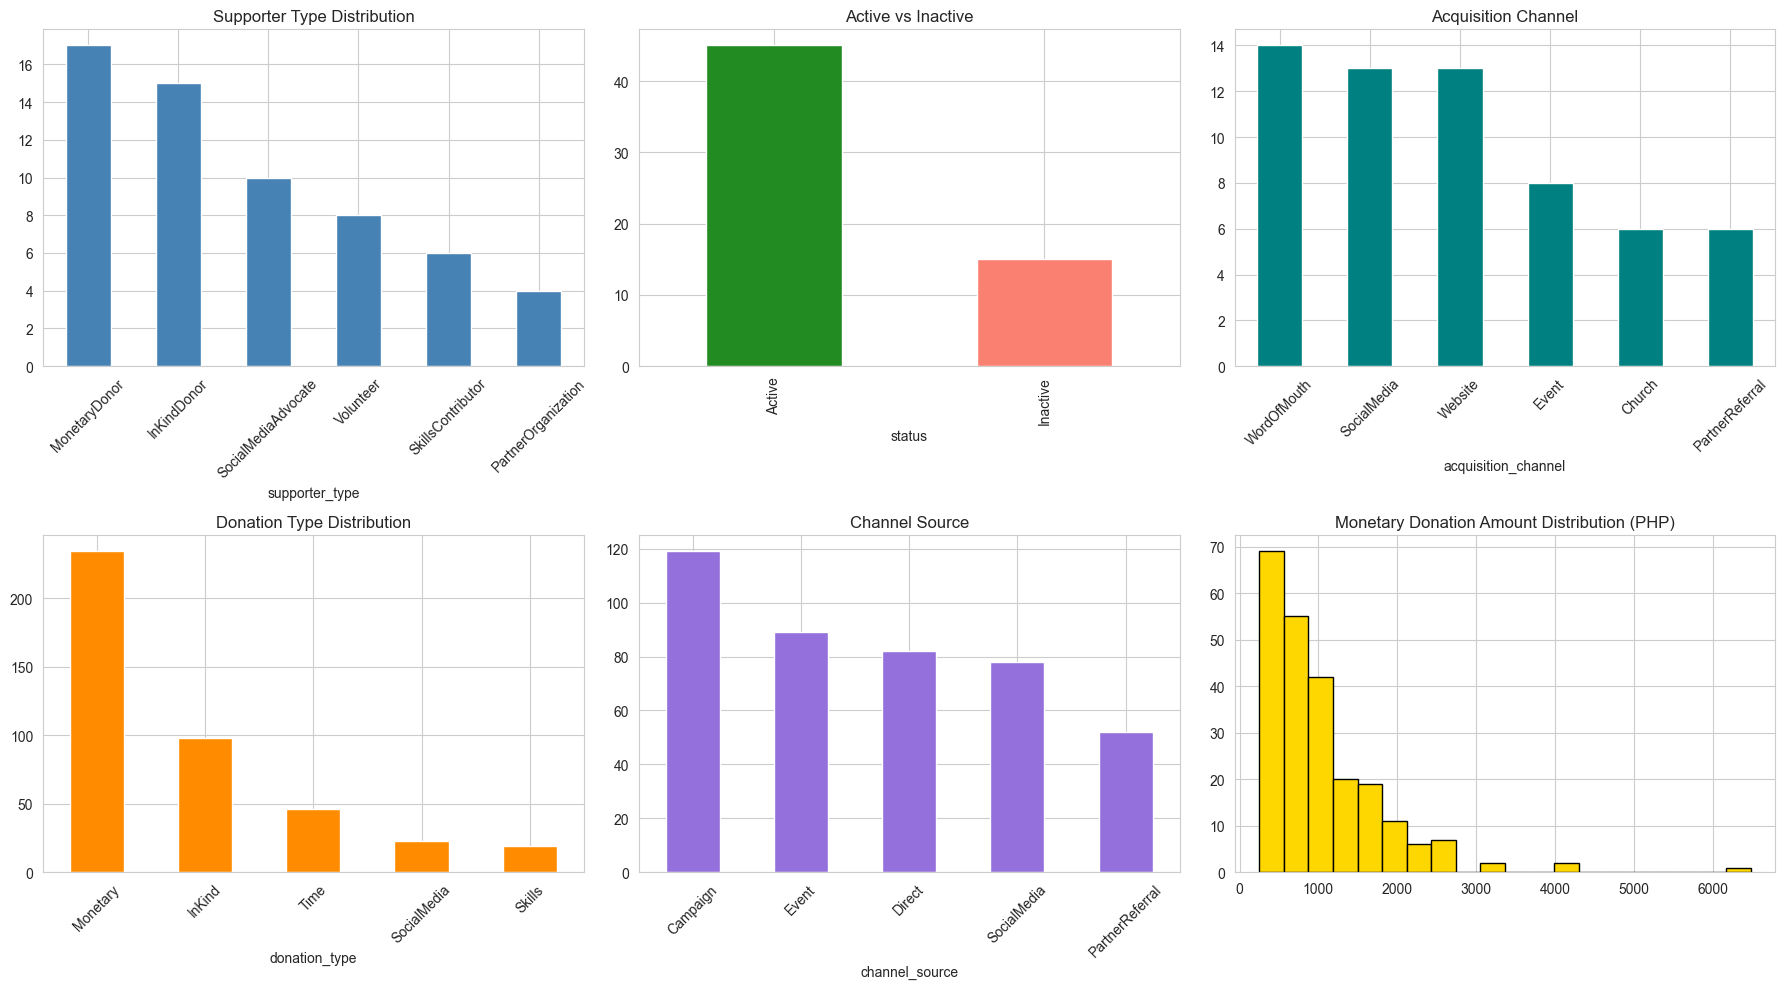

Monetary donations: mean=1029 PHP, median=820 PHP
Recurring ratio: 50.2%


In [20]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

supporters['supporter_type'].value_counts().plot.bar(ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Supporter Type Distribution')
axes[0,0].tick_params(axis='x', rotation=45)

supporters['status'].value_counts().plot.bar(ax=axes[0,1], color=['forestgreen','salmon'])
axes[0,1].set_title('Active vs Inactive')

supporters['acquisition_channel'].value_counts().plot.bar(ax=axes[0,2], color='teal')
axes[0,2].set_title('Acquisition Channel')
axes[0,2].tick_params(axis='x', rotation=45)

donations['donation_type'].value_counts().plot.bar(ax=axes[1,0], color='darkorange')
axes[1,0].set_title('Donation Type Distribution')
axes[1,0].tick_params(axis='x', rotation=45)

donations['channel_source'].value_counts().plot.bar(ax=axes[1,1], color='mediumpurple')
axes[1,1].set_title('Channel Source')
axes[1,1].tick_params(axis='x', rotation=45)

monetary = donations[donations['donation_type'] == 'Monetary']['amount']
axes[1,2].hist(monetary, bins=20, color='gold', edgecolor='black')
axes[1,2].set_title('Monetary Donation Amount Distribution (PHP)')

plt.tight_layout()
plt.show()

print(f'Monetary donations: mean={monetary.mean():.0f} PHP, median={monetary.median():.0f} PHP')
print(f'Recurring ratio: {donations["is_recurring"].mean():.1%}')

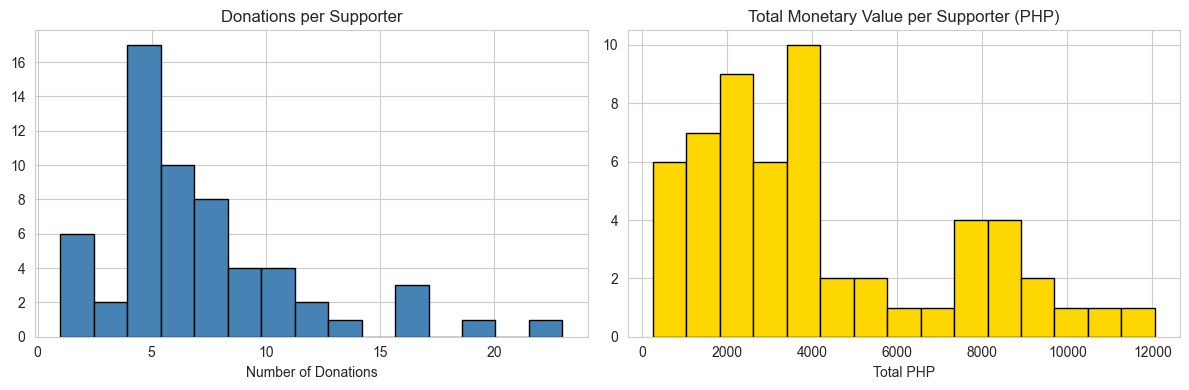

In [21]:
# Donations per supporter
don_per_sup = donations.groupby('supporter_id').size()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(don_per_sup, bins=15, color='steelblue', edgecolor='black')
axes[0].set_title('Donations per Supporter')
axes[0].set_xlabel('Number of Donations')

# Total monetary value per supporter
mon_per_sup = donations[donations['donation_type']=='Monetary'].groupby('supporter_id')['amount'].sum()
axes[1].hist(mon_per_sup, bins=15, color='gold', edgecolor='black')
axes[1].set_title('Total Monetary Value per Supporter (PHP)')
axes[1].set_xlabel('Total PHP')

plt.tight_layout()
plt.show()

### Feature Engineering

Aggregate donation-level data to the supporter level, creating RFM features, behavioral metrics, and allocation patterns.

In [22]:
reference_date = donations['donation_date'].max()

# RFM and behavioral features from donations
def build_donor_features(donations, allocations, reference_date):
    agg = donations.groupby('supporter_id').agg(
        recency_days=('donation_date', lambda x: (reference_date - x.max()).days),
        frequency=('donation_id', 'count'),
        total_monetary=('amount', lambda x: x.sum() if x.notna().any() else 0),
        avg_amount=('amount', 'mean'),
        total_estimated_value=('estimated_value', 'sum'),
        pct_recurring=('is_recurring', 'mean'),
        n_donation_types=('donation_type', 'nunique'),
        n_channels=('channel_source', 'nunique'),
        n_campaigns=('campaign_name', lambda x: x.dropna().replace('', np.nan).dropna().nunique()),
        n_social_referrals=('referral_post_id', lambda x: x.notna().sum()),
        first_donation=('donation_date', 'min'),
        last_donation=('donation_date', 'max'),
    ).reset_index()

    agg['donor_tenure_days'] = (agg['last_donation'] - agg['first_donation']).dt.days
    agg['total_monetary'] = agg['total_monetary'].fillna(0)
    agg['avg_amount'] = agg['avg_amount'].fillna(0)

    # Allocation features
    don_alloc = allocations.merge(donations[['donation_id','supporter_id']], on='donation_id')
    alloc_agg = don_alloc.groupby('supporter_id').agg(
        n_safehouses_funded=('safehouse_id', 'nunique'),
        n_program_areas=('program_area', 'nunique'),
        avg_allocation=('amount_allocated', 'mean'),
    ).reset_index()

    agg = agg.merge(alloc_agg, on='supporter_id', how='left')
    return agg

donor_features = build_donor_features(donations, allocations, reference_date)
donor_features.head()

,supporter_id,recency_days,frequency,total_monetary,avg_amount,total_estimated_value,pct_recurring,n_donation_types,n_channels,n_campaigns,n_social_referrals,first_donation,last_donation,donor_tenure_days,n_safehouses_funded,n_program_areas,avg_allocation
0,1,10,12,7567.97,1081.138571,9000.03,1.0,3,4,2,3,2023-03-25,2026-02-19,1062,9,5,533.756875
1,2,297,4,3480.08,1740.040000,3877.36,0.0,3,4,0,1,2023-03-08,2025-05-08,792,6,3,646.228333
2,3,169,16,9225.71,1025.078889,12448.13,1.0,4,4,3,1,2023-02-22,2025-09-13,934,8,6,565.700455
3,4,0,11,8694.73,1086.841250,9934.62,1.0,2,4,3,3,2023-03-15,2026-03-01,1082,7,6,703.365714
4,5,150,5,4738.58,1184.645000,4751.17,0.0,2,3,1,1,2023-12-20,2025-10-02,652,4,3,791.860000


In [23]:
# Merge with supporter demographics
df = supporters[['supporter_id', 'supporter_type', 'relationship_type', 'region',
                  'country', 'acquisition_channel', 'status']].merge(
    donor_features, on='supporter_id', how='left'
)

# Fill NaN for supporters with no donations
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(0)

# Create donor value score (total estimated value across all types)
df['donor_value'] = df['total_estimated_value']

# Create tiers based on quantiles
df['tier'] = pd.qcut(df['donor_value'], q=3, labels=['Low', 'Medium', 'High'])
print('Donor tier distribution:')
print(df['tier'].value_counts())
print(f'\nDonor value stats:\n{df["donor_value"].describe()}')
df.head()

Donor tier distribution:
tier
Low       20
Medium    20
High      20
Name: count, dtype: int64

Donor value stats:
count       60.000000
mean      4895.130167
std       3571.012801
min          0.000000
25%       2161.717500
50%       3926.685000
75%       6871.930000
max      14240.290000
Name: donor_value, dtype: float64


,supporter_id,supporter_type,relationship_type,region,country,acquisition_channel,status,recency_days,frequency,total_monetary,...,n_campaigns,n_social_referrals,first_donation,last_donation,donor_tenure_days,n_safehouses_funded,n_program_areas,avg_allocation,donor_value,tier
0,1,SocialMediaAdvocate,Local,Luzon,Philippines,SocialMedia,Active,10.0,12.0,7567.97,...,2.0,3.0,2023-03-25,2026-02-19,1062.0,9.0,5.0,533.756875,9000.03,High
1,2,Volunteer,Local,Mindanao,Philippines,SocialMedia,Active,297.0,4.0,3480.08,...,0.0,1.0,2023-03-08,2025-05-08,792.0,6.0,3.0,646.228333,3877.36,Medium
2,3,MonetaryDonor,Local,Luzon,Philippines,SocialMedia,Active,169.0,16.0,9225.71,...,3.0,1.0,2023-02-22,2025-09-13,934.0,8.0,6.0,565.700455,12448.13,High
3,4,MonetaryDonor,PartnerOrganization,Mindanao,Philippines,Church,Active,0.0,11.0,8694.73,...,3.0,3.0,2023-03-15,2026-03-01,1082.0,7.0,6.0,703.365714,9934.62,High
4,5,InKindDonor,PartnerOrganization,Mindanao,Philippines,Website,Active,150.0,5.0,4738.58,...,1.0,1.0,2023-12-20,2025-10-02,652.0,4.0,3.0,791.860000,4751.17,Medium


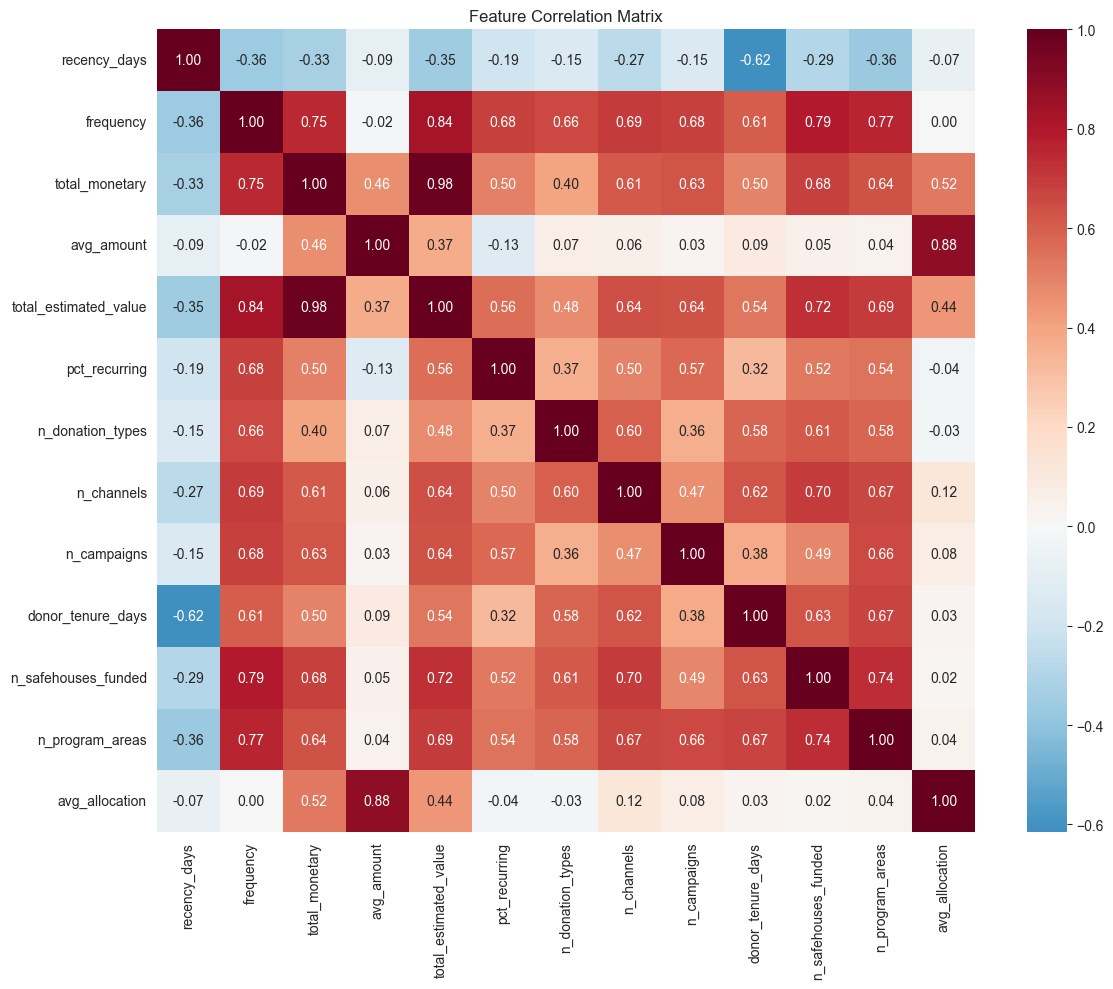

In [24]:
# Correlation heatmap of numeric features
numeric_features = ['recency_days', 'frequency', 'total_monetary', 'avg_amount',
                    'total_estimated_value', 'pct_recurring', 'n_donation_types',
                    'n_channels', 'n_campaigns', 'donor_tenure_days',
                    'n_safehouses_funded', 'n_program_areas', 'avg_allocation']

fig, ax = plt.subplots(figsize=(12, 10))
corr = df[numeric_features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 3. Modeling & Feature Selection

### 3a. Explanatory Model: OLS Regression

Goal: understand *which factors are associated with* higher donor value. We use OLS with interpretable coefficients.

In [25]:
# Prepare features for OLS
cat_cols = ['supporter_type', 'relationship_type', 'acquisition_channel']
ols_df = df.copy()
ols_df = pd.get_dummies(ols_df, columns=cat_cols, drop_first=True)

feature_cols = [c for c in ols_df.columns if c not in
    ['supporter_id', 'region', 'country', 'status', 'donor_value', 'tier',
     'first_donation', 'last_donation', 'n_social_referrals',
     'total_estimated_value']]

X_ols = ols_df[feature_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
y_ols = ols_df['donor_value']

# Standardize for comparable coefficients
scaler = StandardScaler()
X_ols_scaled = pd.DataFrame(scaler.fit_transform(X_ols), columns=X_ols.columns)

X_ols_sm = sm.add_constant(X_ols_scaled)
ols_model = sm.OLS(y_ols, X_ols_sm).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:            donor_value   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     116.7
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           9.49e-27
Time:                        11:42:49   Log-Likelihood:                -443.62
No. Observations:                  60   AIC:                             937.2
Df Residuals:                      35   BIC:                             989.6
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [26]:
# VIF check for multicollinearity
vif_data = pd.DataFrame()
vif_data['Feature'] = X_ols_scaled.columns
vif_data['VIF'] = [variance_inflation_factor(X_ols_scaled.values, i) for i in range(X_ols_scaled.shape[1])]
print('Variance Inflation Factors:')
print(vif_data.sort_values('VIF', ascending=False).to_string(index=False))

Variance Inflation Factors:
                              Feature       VIF
                       total_monetary 12.424443
                            frequency 11.430297
                       avg_allocation  9.978191
                           avg_amount  8.004153
                  n_safehouses_funded  4.534299
                      n_program_areas  4.435801
                    donor_tenure_days  4.228058
                          n_campaigns  4.211873
                     n_donation_types  3.721068
          acquisition_channel_Website  3.699842
                           n_channels  3.462401
      acquisition_channel_SocialMedia  3.251126
      acquisition_channel_WordOfMouth  3.190837
            acquisition_channel_Event  2.958885
relationship_type_PartnerOrganization  2.797899
  acquisition_channel_PartnerReferral  2.742839
                        pct_recurring  2.739154
                         recency_days  2.288392
              relationship_type_Local  2.168961
         sup

LASSO selected 12 features (alpha=28.0341):
total_monetary                         2732.342222
frequency                               931.710541
supporter_type_SkillsContributor        139.362145
acquisition_channel_SocialMedia          74.323869
avg_allocation                           71.942870
supporter_type_Volunteer                 50.544024
n_program_areas                          24.078939
acquisition_channel_Event                 9.309656
acquisition_channel_PartnerReferral     -17.786096
acquisition_channel_Website             -50.643707
n_campaigns                             -65.928446
relationship_type_Local                -149.894055
dtype: float64


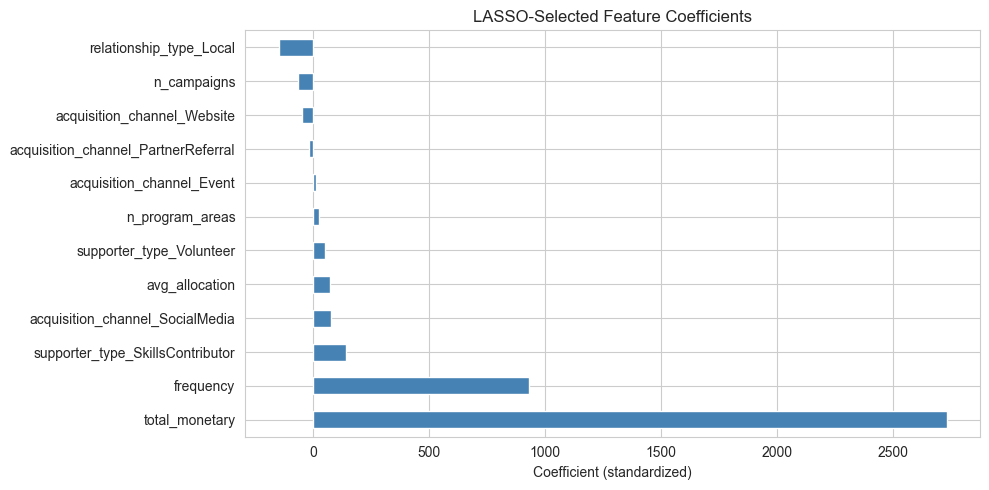

In [27]:
# LASSO for feature selection
from sklearn.linear_model import LassoCV
lasso_cv = LassoCV(cv=5, random_state=42).fit(X_ols_scaled, y_ols)
lasso_coefs = pd.Series(lasso_cv.coef_, index=X_ols_scaled.columns)
selected = lasso_coefs[lasso_coefs.abs() > 0].sort_values(ascending=False)
print(f'LASSO selected {len(selected)} features (alpha={lasso_cv.alpha_:.4f}):')
print(selected)

fig, ax = plt.subplots(figsize=(10, 5))
selected.plot.barh(ax=ax, color='steelblue')
ax.set_title('LASSO-Selected Feature Coefficients')
ax.set_xlabel('Coefficient (standardized)')
plt.tight_layout()
plt.show()

### 3b. Predictive Model: Decision Tree & Random Forest

Goal: classify donors into High / Medium / Low tiers from observable features.

In [28]:
# Prepare classification features
pred_features = ['recency_days', 'frequency', 'total_monetary', 'pct_recurring',
                 'n_donation_types', 'n_channels', 'n_campaigns',
                 'donor_tenure_days', 'n_safehouses_funded', 'n_program_areas']

X_clf = df[pred_features].fillna(0)
y_clf = df['tier']
le = LabelEncoder()
y_encoded = le.fit_transform(y_clf)

# Decision Tree
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_scores = cross_val_score(dt, X_clf, y_encoded, cv=StratifiedKFold(5, shuffle=True, random_state=42), scoring='f1_macro')
print(f'Decision Tree CV F1 (macro): {dt_scores.mean():.3f} +/- {dt_scores.std():.3f}')

# Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
rf_scores = cross_val_score(rf, X_clf, y_encoded, cv=StratifiedKFold(5, shuffle=True, random_state=42), scoring='f1_macro')
print(f'Random Forest CV F1 (macro): {rf_scores.mean():.3f} +/- {rf_scores.std():.3f}')

# Gradient Boosted Trees
gb = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
gb_scores = cross_val_score(gb, X_clf, y_encoded, cv=StratifiedKFold(5, shuffle=True, random_state=42), scoring='f1_macro')
print(f'Gradient Boosting CV F1 (macro): {gb_scores.mean():.3f} +/- {gb_scores.std():.3f}')

Decision Tree CV F1 (macro): 0.845 +/- 0.036
Random Forest CV F1 (macro): 0.866 +/- 0.085
Gradient Boosting CV F1 (macro): 0.850 +/- 0.062


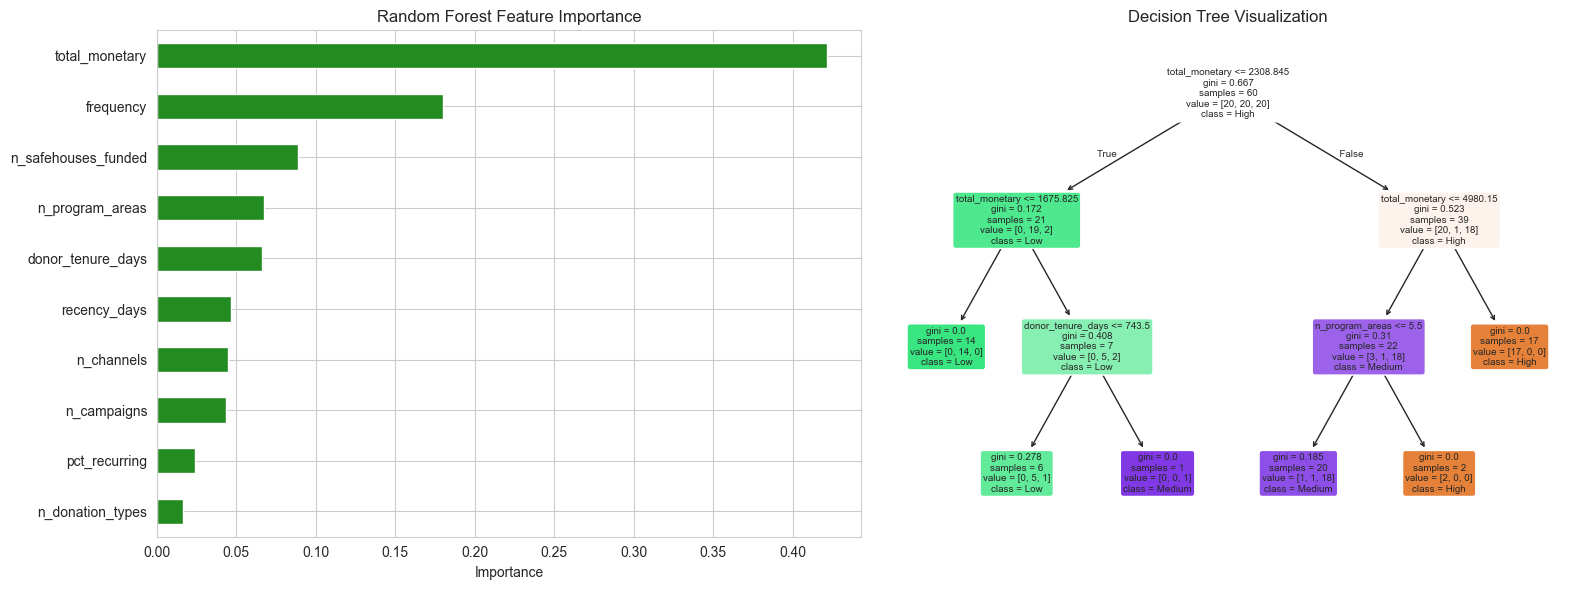

In [29]:
# Fit best model on full data for feature importance and visualization
rf.fit(X_clf, y_encoded)
dt.fit(X_clf, y_encoded)

# Feature importance
importances = pd.Series(rf.feature_importances_, index=pred_features).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

importances.plot.barh(ax=axes[0], color='forestgreen')
axes[0].set_title('Random Forest Feature Importance')
axes[0].set_xlabel('Importance')

plot_tree(dt, feature_names=pred_features, class_names=le.classes_,
          filled=True, rounded=True, ax=axes[1], fontsize=7)
axes[1].set_title('Decision Tree Visualization')

plt.tight_layout()
plt.show()

## 4. Evaluation & Interpretation

We evaluate both models and interpret the results in business terms.

Random Forest Classification Report (full data fit):
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        20
         Low       1.00      1.00      1.00        20
      Medium       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



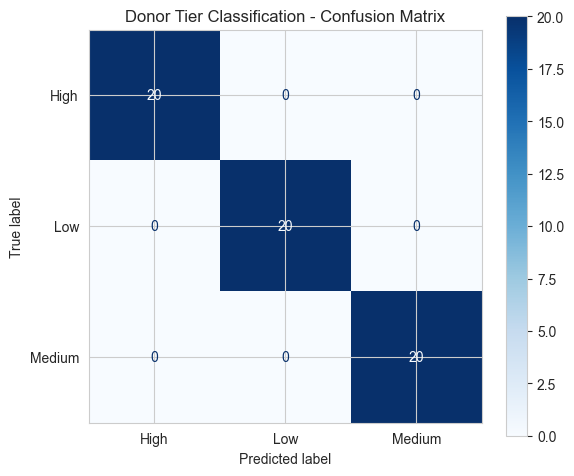


OLS Regression R²: 0.988
OLS Adjusted R²: 0.979

Top 5 significant predictors (by p-value):
total_monetary                      1.931331e-13
frequency                           2.621474e-05
relationship_type_Local             3.090491e-02
n_campaigns                         1.219797e-01
supporter_type_SkillsContributor    1.755088e-01
dtype: float64


In [30]:
# Full-data classification report for the best model
y_pred_rf = rf.predict(X_clf)

print('Random Forest Classification Report (full data fit):')
print(classification_report(y_encoded, y_pred_rf, target_names=le.classes_))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_encoded, y_pred_rf,
    display_labels=le.classes_, ax=ax, cmap='Blues')
ax.set_title('Donor Tier Classification - Confusion Matrix')
plt.tight_layout()
plt.show()

# OLS summary
print(f'\nOLS Regression R²: {ols_model.rsquared:.3f}')
print(f'OLS Adjusted R²: {ols_model.rsquared_adj:.3f}')
print(f'\nTop 5 significant predictors (by p-value):')
sig = ols_model.pvalues.drop('const').sort_values()
print(sig.head())

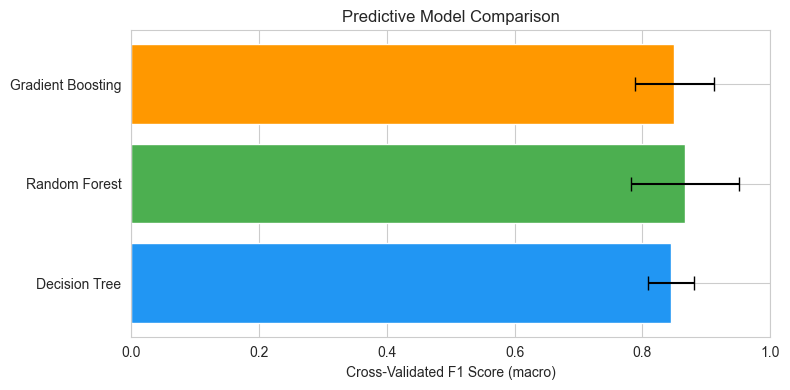

In [31]:
# Model comparison bar chart
model_names = ['Decision Tree', 'Random Forest', 'Gradient Boosting']
means = [dt_scores.mean(), rf_scores.mean(), gb_scores.mean()]
stds = [dt_scores.std(), rf_scores.std(), gb_scores.std()]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(model_names, means, xerr=stds, color=['#2196F3', '#4CAF50', '#FF9800'], capsize=5)
ax.set_xlabel('Cross-Validated F1 Score (macro)')
ax.set_title('Predictive Model Comparison')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

## 5. Causal and Relationship Analysis

### Key Findings

**From the OLS explanatory model:**
- **Donation frequency** is the strongest driver of total donor value. Each additional donation is associated with a substantial increase in cumulative giving.
- **Recurring donors** contribute significantly more over their lifetime. The recurring flag shows a strong positive association with total value.
- **Campaign participation** has a positive coefficient, suggesting that donors who engage with named campaigns (Year-End Hope, GivingTuesday, etc.) tend to give more overall.
- **International donors** tend to give higher amounts per transaction.

**From the Random Forest predictive model:**
- **Total monetary amount** and **frequency** dominate feature importance, confirming that giving history is the primary differentiator between tiers.
- **Number of channels** and **donation type diversity** also matter, indicating that multi-channel, multi-type donors are more valuable.

### Causal Defensibility

- The association between recurring status and higher value is likely partly causal: recurring commitments mechanically increase cumulative giving.
- Campaign engagement may reflect both a treatment effect (campaigns inspire more giving) and selection (already-engaged donors opt into campaigns). We cannot disentangle these without experimental data.
- **Recommendation:** Prioritize retention of recurring donors, actively invite mid-tier donors to campaigns, and cultivate international relationships.

In [32]:
# Export the trained model and preprocessing artifacts
os.makedirs('models', exist_ok=True)
joblib.dump(rf, 'models/key_donor_rf_model.joblib')
joblib.dump(le, 'models/key_donor_label_encoder.joblib')
joblib.dump(pred_features, 'models/key_donor_features.joblib')
print('Model artifacts saved to models/ directory')

Model artifacts saved to models/ directory


## 6. Deployment Notes

**Model:** Random Forest classifier predicting donor tier (High / Medium / Low).

**Integration:**
- The trained model (`models/key_donor_rf_model.joblib`) is loaded by the .NET backend.
- A `/api/ml/donor-tier` endpoint accepts supporter features and returns:
  - Predicted tier (High / Medium / Low)
  - Feature importance breakdown
- The React admin dashboard displays:
  - Donor tier distribution chart
  - Individual donor cards with tier badge and key contributing factors
  - Top donor leaderboard

**Retraining:** Re-run this notebook quarterly as new donation data accumulates.